# Fraud Detection - Modeling & Evaluation

## Objectives

In this notebook I train and evaluate two classification models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as the baseline model and Random Forest to capture any non-linear relationships. I use `RandomizedSearchCV` (does cross-valudation internally, ensuring evaluation reliability) on stratified subsample for hyperparameter tuning. Model performance is evaluated using accuracy, recall, precision, F1-score, AUC-ROC, and PR-AUC — with an emphasis on recall since false negatives (missed fraud cases) are more costly than false positives (misclassifying legit cases as fraud). Lastly, I apply segmentation analysis on transaction type to verify the model's reliability across different transaction types — fraud cases were concentrated in only two of the different transaction types, so focusing on which transactions to focus on can save businesses time and resources. 

## Output

- Trained Logistic Regression and Random Forest models
- Recommended model with performance metrics
- Justification for model choice and business relevance
- Visualizations for README

## 3.1 Setup & Imports
Importing most of the same libraries and absolute paths like numpy, pandas, and X and y train/test paths. Addition of sklearn model libraries for Logistic Regression, Random Forest, `RandomizedSearchCV`, evaluation metrics, as well as graphing libraries for README visualization.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay, precision_recall_curve


RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.parquet'
X_TEST_PATH = '../data/processed/X_test.parquet'
Y_TRAIN_PATH = '../data/processed/y_train.parquet'
Y_TEST_PATH = '../data/processed/y_test.parquet'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in section `3.1`. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format sklearn models expect for target variables.

(Note: an earlier version of this notebook surfaced a `NaN` issue in `X_train` traced back to `oldbalanceOrg == 0`; this was resolved upstream in `02_feature_engineering.ipynb`, section `2.4.5`.)

In [13]:
X_train = pd.read_parquet(X_TRAIN_PATH)
X_test = pd.read_parquet(X_TEST_PATH)
y_train = pd.read_parquet(Y_TRAIN_PATH).squeeze()
y_test = pd.read_parquet(Y_TEST_PATH).squeeze()

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5069097, 13), (1293523, 13), (5069097,), (1293523,))

`.shape` confirms the four datasets were loaded correctly — `X_train` ((5069097, 13)), `X_test` (1293523, 13), `y_train` (5069097,), `y_test` (1293523,) — matching the expected shapes from `02_feature_engineering.ipynb` and confirming 1D target series after `.squeeze()`.

## 3.3 Handle Class Imbalance

I use class weighting to handle the class imbalance since it doesn't require data modification, and undersampling or oversampling/SMOTE would either discard too much real data or be computationally impractical given the ~5M training set rows. This will be implemented by passing `class_weight='balanced'` into the classification models. 

## 3.4 Baseline Model: Logistic Regression

I implement Logistic Regression as the baseline model using sklearn's `LogisticRegression`. This is an appropriate baseline because it models the linear relationship between features and the log-odds of the target (`isFraud`), is highly interpretable, and serves as a strong reference point before introducing more complex models like Random Forest. The model is fit on `X_train` and `y_train`, then used to generate both class predictions and probability scores for PR-AUC/AUC-ROC evaluation. `random_state=RANDOM_STATE` ensures reproducibility. 

In [ ]:
# create logistic regression
lr = LogisticRegression(random_state= RANDOM_STATE, class_weight='balanced')
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

To evaluate performance I report accuracy, precision, recall, F1-score, AUC-ROC, and PR-AUC — with recall on class 1 (`isFraud=1`) as the most important metric since missing a fraud case is more costly than a false alarm. I also produce a confusion matrix heatmap to visualize TP, TN, FP, and FN counts directly.

In [16]:
# evaluation metrics
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_lr))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1289265
           1       0.07      0.90      0.12      4258

    accuracy                           0.96   1293523
   macro avg       0.53      0.93      0.55   1293523
weighted avg       1.00      0.96      0.98   1293523

AUC-ROC score: 0.9628430838076574
PR-AUC score: 0.6236992314838238


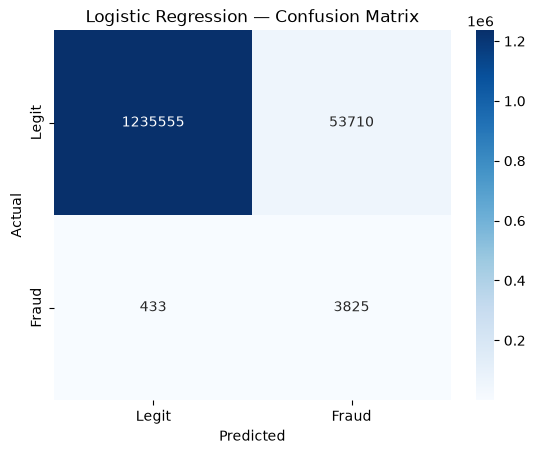

In [17]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Logistic_Regression_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

## 3.5 Random Forest Model

## 3.6 Hyperparameter Tuning

## 3.7 Model Comparisons

## 3.8 Retrain Best Model: [Fill]

## 3.9 Evaluation: PR Curve & ROC Curve 

## 3.10 Feature Importance

## 3.11 Final Model Comparison

## 3.12 Segementation Analysis 

## 3.13 Model Recommendation / Limitations